## Oxygen in Si

In [1]:
import math as m
from scipy import special as s
from matplotlib import pyplot as plt
import numpy as np

In [2]:
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 18,
        }
font_s = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
        }
font_title = {'family': 'serif',
        'weight': 'normal',
        'size': 18,
        }

In [3]:
T = 300
k = 1.380649*pow(10,-23)
k_ev = 8.617333262*pow(10,-5)
h = 6.62607015*pow(10,-34)

In [4]:
def o_si(temp):
    a = 5.5*pow(10,20)
    o = a*m.exp(-0.89/(k_ev*temp))
    return o
o_si(550)

3846672938311.0366

In [5]:
# Sillicon atomic concentration is
o = pow(10,18) #20 ppm Si atomi con = 5e22
o_si(1636.797)

1.0000208822777846e+18

In [6]:
def delg(temp):
    """Returns energy in Joules"""
    return 6700*(1350-temp)/1350
delg(550)

3970.3703703703704

In [7]:
def surface_en(r):
    gamma = 4.30*pow(10,-5)
    area = 4*m.pi*r*r
    return gamma*area
def g_crit(gamma,temp):
    n = 16*m.pi*pow(gamma,3)
    d = 3*delg(temp)*delg(temp)
    return n/d


In [8]:
gamma = 4.30*pow(10,-5)
-2*gamma/delg(550)

-2.166044776119403e-08

In [9]:
g_crit(4.3*pow(10,-5),550)

8.450685220466441e-20

In [10]:
gamma = 4.30*pow(10,-5)
def nuc_den(temp,gamma):
    no = pow(10,18)
    n = no*m.exp(-g_crit(gamma,temp)/(k*temp))
    return n

In [11]:
tem = np.linspace(214,731,48)
n = [nuc_den(i,gamma) for i in tem]
tem

array([214., 225., 236., 247., 258., 269., 280., 291., 302., 313., 324.,
       335., 346., 357., 368., 379., 390., 401., 412., 423., 434., 445.,
       456., 467., 478., 489., 500., 511., 522., 533., 544., 555., 566.,
       577., 588., 599., 610., 621., 632., 643., 654., 665., 676., 687.,
       698., 709., 720., 731.])

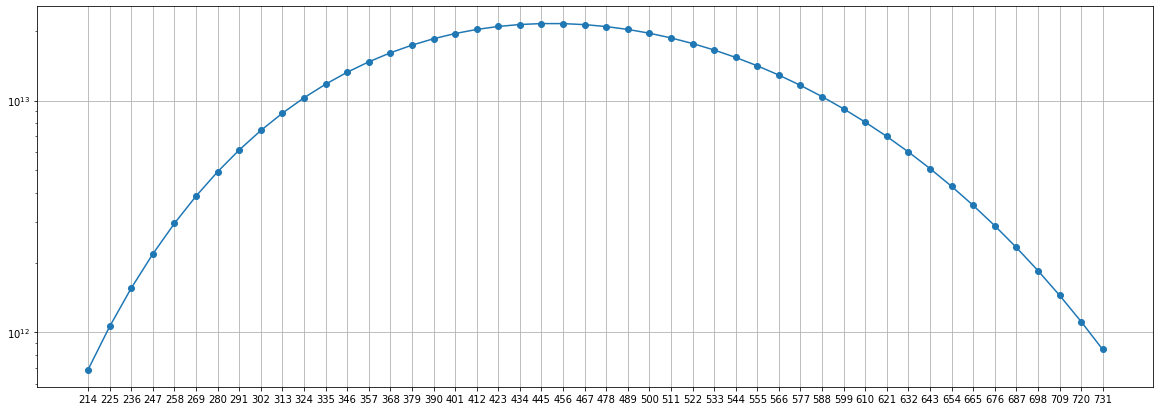

In [12]:
plt.figure(figsize=(20,7))
plt.plot(tem,n, marker = 'o')
plt.grid(visible=None, which='major')
plt.xticks(tem)
plt.yscale('log')

In [13]:
nuc_den(715,gamma)

1256272817716.8184

In [14]:
def diffusion(temp):
    ea = -2.44
    do = 7*pow(10,-2)
    d = do*m.exp(ea/(k_ev*temp))
    return d

def R(temp):
    r = -2*gamma/delg(temp)
    z = pow(10,-3)
    D = diffusion(temp)
    no = pow(10,18)
    a = 2.35*pow(10,-8) #2.35 angstrom written in cm
    v = 4*m.pi*pow(r,2)*z*no*D/a
    rate = nuc_den(temp,gamma)*v
    return rate


In [15]:
tem2 = np.linspace(400,1000,61)
rate = [R(i) for i in tem2]
tem2


array([ 400.,  410.,  420.,  430.,  440.,  450.,  460.,  470.,  480.,
        490.,  500.,  510.,  520.,  530.,  540.,  550.,  560.,  570.,
        580.,  590.,  600.,  610.,  620.,  630.,  640.,  650.,  660.,
        670.,  680.,  690.,  700.,  710.,  720.,  730.,  740.,  750.,
        760.,  770.,  780.,  790.,  800.,  810.,  820.,  830.,  840.,
        850.,  860.,  870.,  880.,  890.,  900.,  910.,  920.,  930.,
        940.,  950.,  960.,  970.,  980.,  990., 1000.])

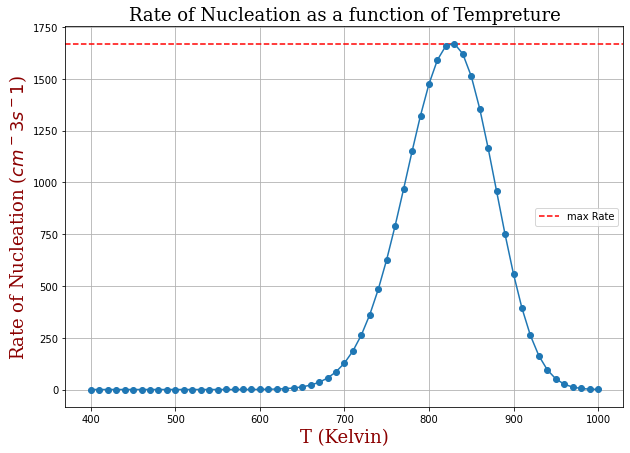

In [16]:
plt.figure(figsize=(10,7))
# plt.xticks(tem2)
plt.axhline(y=R(830), linestyle = '--', color = 'red',label = 'max Rate')
plt.plot(tem2,rate, marker = 'o')
plt.title(r'Rate of Nucleation as a function of Tempreture', fontdict = font_title)
plt.ylabel('Rate of Nucleation ($cm^-3 s^-1$)',fontdict = font)
plt.xlabel('T (Kelvin)',fontdict = font)
plt.grid(visible=None, which='major')
# plt.xlim(700,1000)
plt.legend()

In [17]:
nuc_den(830,gamma)/(5*pow(10,12))

0.005256532781748205

In [20]:
diffusion(1273)

1.5317689782607315e-11

In [26]:
245*pow(10,-4)*245*pow(10,-4)

0.0006002500000000001

In [65]:
def c(time):
    s = pow(10,18)
    temp = 1373
    d = diffusion(temp)
    result = (s/pow(m.pi*d*time,0.5))*m.exp(-2.5*pow(10,-7)/(4*d*time))
    return result
c(67.25)-5*pow(10,16)


-2285450519743928.0

In [54]:
time = np.linspace(0.0001,80,300)
con = [c(i)-5*pow(10,16) for i in time]

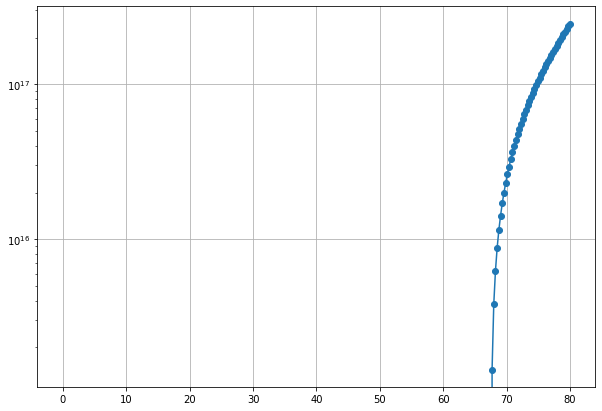

In [67]:
plt.figure(figsize=(10,7))
plt.plot(time,con,marker = 'o')
# plt.xlim(66,70)
# plt.ylim(0,0.5)
plt.yscale('log')
plt.grid(visible=None, which='major')

In [68]:
diffusion(1373)

7.740253088293124e-11

In [69]:
25*pow(10,-8)/(7.74*pow(10,-11))

3229.9741602067184

In [70]:
5/1.13

4.424778761061948

In [71]:
4.4247787610619*4.4247787610619

19.578667084344477

In [72]:
19.5786670843444/7.74

2.5295435509488886